In [ ]:
import pandas as pd
import joblib

# data load
df = pd.read_csv("fraud_data.csv")

# model load
model = joblib.load("fraud_model.pkl")

df.head()   

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


### Feature Importance

In [2]:
importance = model.feature_importances_
feat_imp = pd.Series(importance,index=df.drop('Class',axis=1).columns)

feat_imp.sort_values(ascending=False).head(10) 

V14     0.765420
V7      0.161031
V10     0.020972
V28     0.004759
V8      0.004608
V16     0.003929
V26     0.003602
V4      0.003415
V12     0.003202
Hour    0.002068
dtype: float32

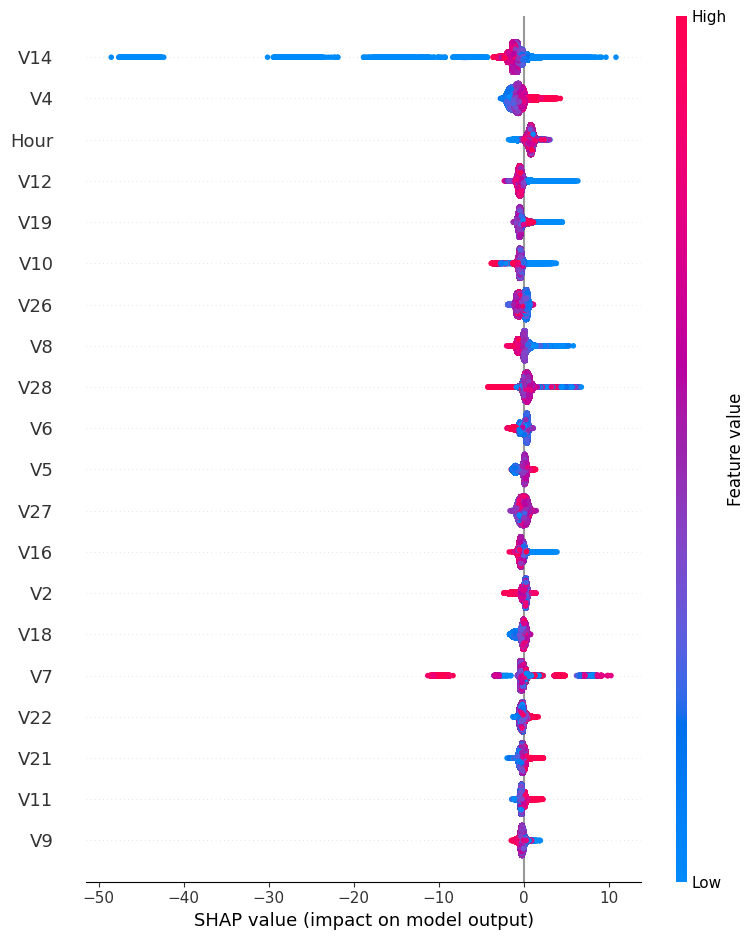

In [3]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df.drop('Class', axis=1))

shap.summary_plot(shap_values, df.drop('Class', axis=1))

In [4]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


### Risk score 

In [5]:
X = df.drop('Class',axis=1)
y = df['Class']

In [6]:
y_prob = model.predict_proba(X)[:,1]

df['fraud_probability'] = y_prob
df['fraud_probability'] = df['fraud_probability'].round(6)
df['risk_score'] = (y_prob*100).astype(int)

df['risk_level'] = pd.cut(
    y_prob,
    bins=[0,0.3,0.6,1],
    labels=['low','medium','high']
)

In [7]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Class,Hour,fraud_probability,risk_score,risk_level
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.000005,0,low
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.000003,0,low
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.000028,0,low
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.000000,0,low
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.000002,0,low


In [8]:
df[df['fraud_probability'] > 0.5]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Class,Hour,fraud_probability,risk_score,risk_level
472,-1.531271,1.399621,-0.587061,2.175002,-2.137637,-0.501576,-1.215215,0.956862,-1.866561,-2.311024,...,0.202522,-0.313118,0.527182,0.202575,204.03,0,0.0,0.753042,75,high
541,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,0.044519,0.177840,0.261145,-0.143276,0.00,1,0.0,1.000000,100,high
4920,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.156114,-0.542628,0.039566,-0.153029,239.93,1,1.0,0.981818,98,high
6108,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.252405,-0.657488,-0.827136,0.849573,59.00,1,1.0,0.999455,99,high
6329,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,1.488901,0.566797,-0.010016,0.146793,1.00,1,2.0,0.906642,90,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,-5.587794,...,0.537503,0.788395,0.292680,0.147968,390.00,1,22.0,1.000000,100,high
280143,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,-3.232153,...,0.521875,0.739467,0.389152,0.186637,0.76,1,23.0,1.000000,100,high
280149,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,...,-0.739695,0.471111,0.385107,0.194361,77.89,1,23.0,1.000000,100,high
281144,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,...,-0.328168,0.606116,0.884876,-0.253700,245.00,1,23.0,1.000000,100,high


In [9]:
df['risk_level'].value_counts() 

risk_level
low       284282
high         480
medium        45
Name: count, dtype: int64

In [ ]:
False_positive = df[(df['Class']==0) & (df['fraud_probability']>0.5)]
False_positive.shape
False_positive.describe()  

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,Hour,fraud_probability,risk_score
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.0,38.000000,38.000000,38.00000
mean,-6.109241,5.201734,-9.473822,3.925944,-4.508499,-2.297883,-6.330761,4.093546,-2.097443,-6.067687,...,-0.043719,0.372238,-0.159693,0.866740,0.350593,61.225000,0.0,7.421053,0.744985,74.00000
std,8.489661,4.369424,8.070192,2.253837,6.578568,1.751486,6.310688,5.088083,1.353200,3.595871,...,0.285403,0.715247,0.283649,0.911077,0.329075,101.504326,0.0,5.721612,0.177617,17.72767
min,-32.273470,-0.448796,-32.454198,-1.459105,-23.236403,-5.053209,-22.291962,-0.313370,-4.026880,-11.208723,...,-0.861765,-0.819655,-0.657310,-1.326786,-0.393645,0.000000,0.0,0.000000,0.500136,50.00000
25%,-7.763851,2.329126,-12.004594,2.135926,-6.778866,-3.593907,-9.986247,0.698433,-3.165571,-9.946398,...,-0.181530,-0.029597,-0.288003,0.007973,0.128326,1.000000,0.0,4.000000,0.564995,56.25000
50%,-2.563519,4.176896,-8.296936,4.323372,-2.735862,-2.583365,-4.406000,1.915104,-2.541580,-5.682586,...,-0.023025,0.284329,-0.270733,1.076496,0.380518,27.405000,0.0,6.000000,0.735572,73.00000
75%,-1.430054,6.521250,-3.556505,5.858809,0.029562,-1.125452,-1.420993,5.507224,-1.101506,-3.362449,...,0.085389,0.500186,-0.191886,1.768947,0.602776,89.990000,0.0,10.500000,0.876112,87.00000
max,1.939116,17.930550,-0.587061,6.590421,4.170041,1.643695,0.641565,18.282168,1.196258,-0.542345,...,0.741676,2.343341,0.534870,2.016056,1.080896,587.000000,0.0,23.000000,0.999983,99.00000
